# Zadanie obowiązkowe [0-10] pkt

1. Rozważ zbiór danych [Air Quality](https://archive.ics.uci.edu/dataset/360/air+quality)
1. [0-3 pkt] Dokonaj wstępnego przetwarzania danych. Skomentuj poszczególne kroki i podjęte decyzje. **Uwagi**: 
   1. kluczowe jest zapoznanie się z opisem zbioru danych
   1. nie interesuje nas tu zależność czasowa - nie traktujemy tego zbioru jako serii czasowej. Jednak rozważ użycie miesiąca jako zmiennej kategorycznej
   1. jaką inną zmienną powinniśmy wyłączyć z analizy? Dlaczego?
   1. jako zmienną zależną (*target*) rozważ sumę koncentracji poszczególnych związków (ozn. `GT`). Czy sumę liczymy przed czy po skalowaniu cech?
1. [0-2 pkt] Użyj:
   1. modelu liniowego
   1. modelu liniowego z regularyzcją L1
   1. modelu liniowego z regularyzcją L2
   1. regresji Hubera
1. [0-2 pkt] Porównaj poszczególne modele dla domyślnych parametrów oraz różnych wartości regularyzacji (użyj [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html))
1. [0-1 pkt] Skomentuj uzyskane wyniki m.in. odnośnie wartości RMSE i MAE oraz czasu treningu
1. [0-1 pkt] Zbadaj wpływ wstępnego przetwarzania danych (np. wpływu skorelowanych cech, usuwania zmiennych katagorycznych, normalizacji) na wyniki. W tym celu możesz użyć klasy [Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)
1. [0-1 pkt] Zwizualizuj wartości parametrów, porównując wszystkie modele razem. Jak wybór parametrów wpływa na osiągi modelu?
  
<span style="color:red">**Uwaga:**</span> zadania bez komentarzy i wniosków zostaną ocenione na **0 punktów**

### 1. Import niezbędnych bibliotek i datasetu

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo 
  
air_quality = fetch_ucirepo(id=360) 
X = air_quality.data.features

print(X.head())

        Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  \
0  3/10/2004  18:00:00     2.6         1360       150      11.9   
1  3/10/2004  19:00:00     2.0         1292       112       9.4   
2  3/10/2004  20:00:00     2.2         1402        88       9.0   
3  3/10/2004  21:00:00     2.2         1376        80       9.2   
4  3/10/2004  22:00:00     1.6         1272        51       6.5   

   PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
0           1046      166          1056      113          1692         1268   
1            955      103          1174       92          1559          972   
2            939      131          1140      114          1555         1074   
3            948      172          1092      122          1584         1203   
4            836      131          1205      116          1490         1110   

      T    RH      AH  
0  13.6  48.9  0.7578  
1  13.3  47.7  0.7255  
2  11.9  54.0  0.7502  
3  11.0  60.0  0.7867  
4 

### 2. Wstępne przetwarzanie

In [16]:
X = X.drop(columns=['Time']) # Nie interesuje nas zależność czasowa, usuwam więc kolumnę z czasem (time)
X['Month'] = pd.to_datetime(X['Date']).dt.month.astype('category') # Zamieniam kolumnę z datą na zmienną kategoryczną miesiąc
X = X.drop(columns=['Date'])
X = pd.get_dummies(X, columns=['Month'], drop_first=True) # One-hot encoding
X = X.replace(-200, np.nan) # Missing values są reprezentowane jako -200 (wniosek z opisu), zamieniam je na NaN

print(X.head())

   CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  \
0     2.6       1360.0     150.0      11.9         1046.0    166.0   
1     2.0       1292.0     112.0       9.4          955.0    103.0   
2     2.2       1402.0      88.0       9.0          939.0    131.0   
3     2.2       1376.0      80.0       9.2          948.0    172.0   
4     1.6       1272.0      51.0       6.5          836.0    131.0   

   PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  ...  Month_3  Month_4  \
0        1056.0    113.0        1692.0       1268.0  ...     True    False   
1        1174.0     92.0        1559.0        972.0  ...     True    False   
2        1140.0    114.0        1555.0       1074.0  ...     True    False   
3        1092.0    122.0        1584.0       1203.0  ...     True    False   
4        1205.0    116.0        1490.0       1110.0  ...     True    False   

   Month_5  Month_6  Month_7  Month_8  Month_9  Month_10  Month_11  Month_12  
0    False    False    False   

In [17]:
# Sprawdzam, jak wiele jest brakujących wartości w każdej kolumnie
print("Percentage of missing values in each column:")
print(round(X.isnull().sum() * 100 / len(X), 2))

Percentage of missing values in each column:
CO(GT)           17.99
PT08.S1(CO)       3.91
NMHC(GT)         90.23
C6H6(GT)          3.91
PT08.S2(NMHC)     3.91
NOx(GT)          17.52
PT08.S3(NOx)      3.91
NO2(GT)          17.55
PT08.S4(NO2)      3.91
PT08.S5(O3)       3.91
T                 3.91
RH                3.91
AH                3.91
Month_2           0.00
Month_3           0.00
Month_4           0.00
Month_5           0.00
Month_6           0.00
Month_7           0.00
Month_8           0.00
Month_9           0.00
Month_10          0.00
Month_11          0.00
Month_12          0.00
dtype: float64


In [18]:
X = X.drop(columns=['NMHC(GT)']) # Kolumna NMHC(GT) ma ponad 90% missing values, usuwam ją

#### Eliminacja silnej korelacji

In [19]:
def plot_correlation_matrix(X): # wyświetla macierzy korelacji zmiennych numerycznych dla zbioru X
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    corr = X[numeric_cols].corr()
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
    plt.title("Macierz korelacji zmiennych liczbowych")
    plt.show()

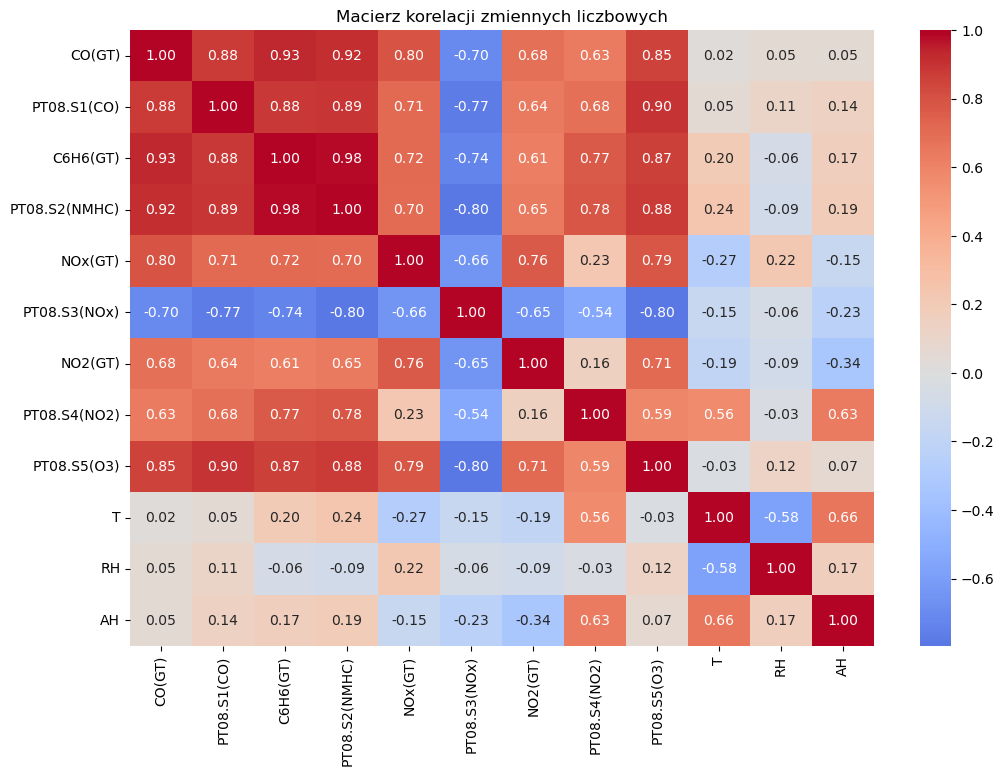

In [20]:
plot_correlation_matrix(X)

In [21]:
def remove_correlation(threshold, X, print_removed=True): # usuwa kolumny, które mają korelację większą niż threshold
    corr_matrix = X.corr()
    to_drop = set()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                to_drop.add(corr_matrix.columns[i])

    if print_removed:
        print(f"Usunięto kolumny z powodu korelacji > {threshold}: {to_drop}")

    X = X.drop(columns=to_drop)
    return X

Usunięto kolumny z powodu korelacji > 0.8: {'C6H6(GT)', 'PT08.S2(NMHC)', 'PT08.S1(CO)', 'PT08.S5(O3)'}


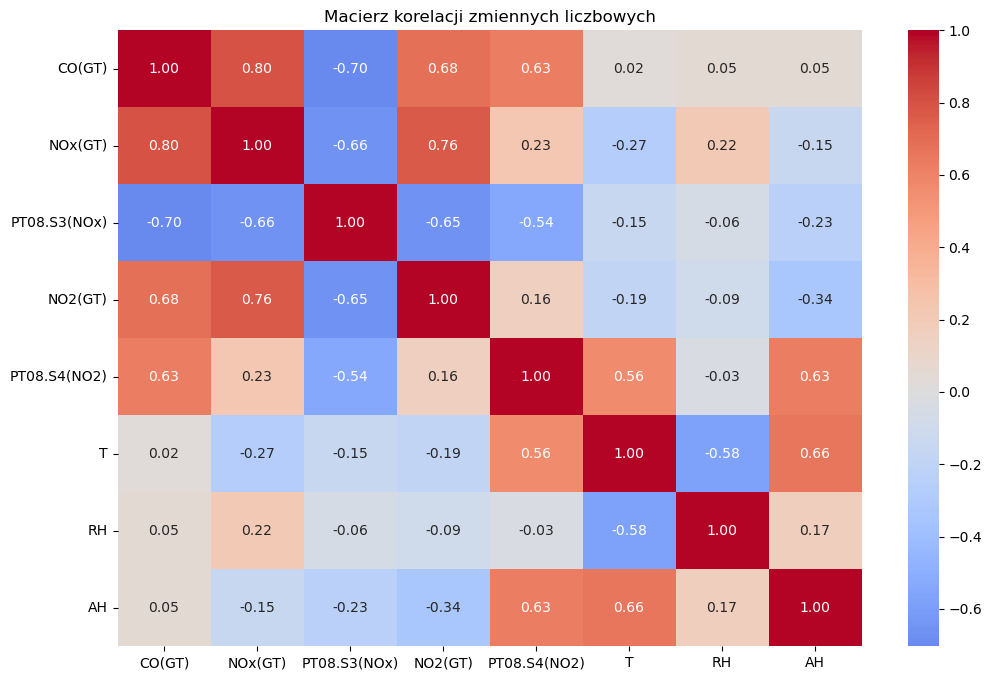

In [22]:
X = remove_correlation(0.8, X) # Usuwam kolumny, które mają |corr| > 0.8
plot_correlation_matrix(X)

In [23]:
# Wyliczam zmienną zależną y jako sumę zmiennych GT (GT1, GT2, GT3, GT4, GT5), robię to przed skalowaniem, żeby nie zmieniać wartości GT
gt_columns = [column for column in X.columns if 'GT' in column]
y = X[gt_columns].sum(axis=1)
X = X.drop(columns=gt_columns)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['category']).columns.tolist()

preprocess = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='mean')), # Uzupełniam brakujące wartości średnią
        ('scaler', StandardScaler()) # Normalizuję zmienne liczbowe
    ]), numeric_cols),
    
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')), # Uzupełniam brakujące wartości najczęściej występującą kategorią
        ('encoder', OneHotEncoder(handle_unknown='ignore')) # Koduję zmienne kategoryczne
    ]), categorical_cols)
])

### 3. Warianty modelu liniowego

In [24]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, HuberRegressor
from sklearn.model_selection import GridSearchCV, train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = { # modele i hiperparametry do przeszukania
    'linear': (LinearRegression(), {}),
    'lasso': (Lasso(), {'model__alpha': [0.001, 0.01, 0.1, 1, 10]}), # L1
    'ridge': (Ridge(), {'model__alpha': [0.001, 0.01, 0.1, 1, 10]}), # L2
    'huber': (HuberRegressor(), {'model__epsilon': [1.1, 1.35, 1.5], 'model__alpha' : [0.001, 0.01, 0.1, 1, 10]}),
}

### 4. Porównanie poszczególnych modeli za pomocą GridSearch

Domyślne parametry

In [25]:
import time
from sklearn.metrics import mean_absolute_error, root_mean_squared_error # metryki

results = []

for name, (model, _) in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocess),
        ('model', model)
    ])

    start_time = time.time()
    pipe.fit(X_train, y_train)
    end_time = time.time()
    best_model = pipe

    y_pred = best_model.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results.append({
        'model': name,
        'rmse': rmse,
        'mae': mae,
        'params': 'default',
        'time': end_time - start_time
    })

GridSearch

In [26]:
for name, (model, param_grid) in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocess),
        ('model', model)
    ])
    
    grid = GridSearchCV(pipe, param_grid, scoring='neg_mean_squared_error', cv=5, n_jobs=-1) if param_grid else model
    
    if param_grid:
        start_time = time.time()
        grid.fit(X_train, y_train)
        end_time = time.time()
        best_model = grid.best_estimator_
    else:
        start_time = time.time()
        pipe.fit(X_train, y_train)
        end_time = time.time()
        best_model = pipe

    y_pred = best_model.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results.append({
        'model': name,
        'rmse': rmse,
        'mae': mae,
        'params': grid.best_params_ if param_grid else {},
        'time': end_time - start_time
    })

print("Wyniki modeli:")
for result in results:
    print(f"Model: {result['model']}, RMSE: {result['rmse']:.2f}, MAE: {result['mae']:.2f}, Czas: {result['time']:.2f} sekundy")
    if result['params']:
        print(f"Najlepsze parametry: {result['params']}")
    print()

Wyniki modeli:
Model: linear, RMSE: 188.96, MAE: 128.36, Czas: 0.01 sekundy
Najlepsze parametry: default

Model: lasso, RMSE: 189.17, MAE: 128.16, Czas: 0.01 sekundy
Najlepsze parametry: default

Model: ridge, RMSE: 188.97, MAE: 128.36, Czas: 0.01 sekundy
Najlepsze parametry: default

Model: huber, RMSE: 190.90, MAE: 126.27, Czas: 0.02 sekundy
Najlepsze parametry: default

Model: linear, RMSE: 188.96, MAE: 128.36, Czas: 0.01 sekundy

Model: lasso, RMSE: 188.98, MAE: 128.34, Czas: 0.11 sekundy
Najlepsze parametry: {'model__alpha': 0.1}

Model: ridge, RMSE: 188.98, MAE: 128.35, Czas: 0.10 sekundy
Najlepsze parametry: {'model__alpha': 10}

Model: huber, RMSE: 190.26, MAE: 126.52, Czas: 0.32 sekundy
Najlepsze parametry: {'model__alpha': 0.01, 'model__epsilon': 1.5}



[KOMENTARZ] 5. Modele osiągnęły dosyć podobne wyniki, przy czym trening tych z przeszukiwaniem hiperparametrów był znacznie dłuższy. Najdłuższy trening dotyczył modelu Huber, który miał ich do przeszukania najwięcej.

### 6. Badanie wpływu wstępnego przetwarzania danych

In [ ]:
from sklearn.model_selection import cross_val_score

pipelin_no_cat = Pipeline([ # pipeline bez zmiennych kategorycznych
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('model', Ridge())
])

pipeline_unscaled = Pipeline([ # pipeline bez skalowania
    ('imputer', SimpleImputer(strategy='mean')),
    ('model', Ridge())
])

scores_scaled_rmse = cross_val_score(pipelin_no_cat, X, y, cv=5, scoring='neg_root_mean_squared_error')
scores_unscaled_rmse = cross_val_score(pipeline_unscaled, X, y, cv=5, scoring='neg_root_mean_squared_error')

scores_scaled_mae = cross_val_score(pipelin_no_cat, X, y, cv=5, scoring='neg_mean_absolute_error')
scores_unscaled_mae = cross_val_score(pipeline_unscaled, X, y, cv=5, scoring='neg_mean_absolute_error')

print(f'Model bez zmiennych kategorycznych (RMSE): {-scores_scaled_rmse.mean():.2f}, MAE: {-scores_scaled_mae.mean():.2f}')
print(f'Model bez skalowania (RMSE): {-scores_unscaled_rmse.mean():.2f}, MAE: {-scores_unscaled_mae.mean():.2f}')

results.append({
    'model': 'Ridge (no scaling)',
    'rmse': -scores_unscaled_rmse.mean(),
    'mae': -scores_unscaled_mae.mean(),
    'params': {},
    'time': None
})

results.append({
    'model': 'Ridge (scaled, no categorical)',
    'rmse': -scores_scaled_rmse.mean(),
    'mae': -scores_scaled_mae.mean(),
    'params': {},
    'time': None
})

Model bez zmiennych kategorycznych (RMSE): 278.00, MAE: 220.42
Model bez skalowania (RMSE): 276.84, MAE: 219.13


[KOMENTARZ] Brak właściwego przetwarzania znacznie pogorszył wyniki.

### 7. Porównanie wszystkich modeli razem

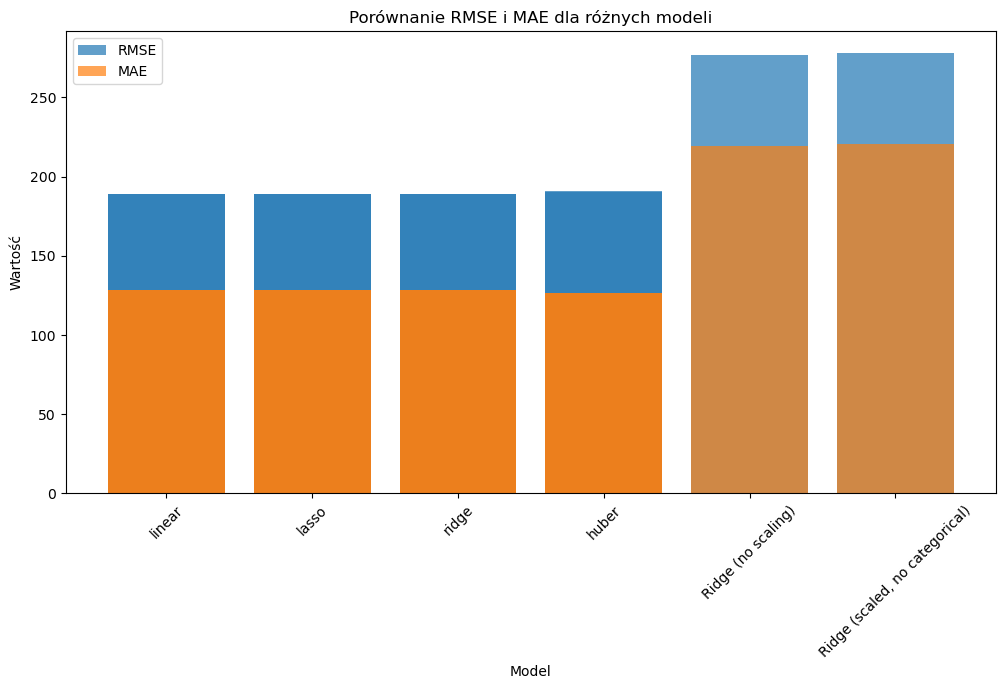

In [28]:
plt.figure(figsize=(12, 6))
plt.bar([result['model'] for result in results], [result['rmse'] for result in results], alpha=0.7, label='RMSE')
plt.bar([result['model'] for result in results], [result['mae'] for result in results], alpha=0.7, label='MAE')
plt.xlabel('Model')
plt.ylabel('Wartość')
plt.title('Porównanie RMSE i MAE dla różnych modeli')
plt.legend()
plt.xticks(rotation=45)
plt.show()

# Zadanie dodatkowe [0-3] pkt

Użyj modelu liniowych efektów mieszanych w zadaniu wyżej:
1. Wykorzystaj API ze [statsmodels](https://www.statsmodels.org/stable/mixed_linear.html)
1. Użyj miesiąca jako zmiennej modelującej efekt losowy (potencjalny *bias*)
1. Skomentuj wyniki w porównaniu do zadania wyżej (miesiąc jako zmienna kategoryczna)

\-